<a href="https://colab.research.google.com/github/arxsyy/PCVK_Ganjil_2026/blob/main/Week5_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Marsyalia Fernanda'
NIM = '244107020133'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)

print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Marsyalia Fernanda
NIM    : 244107020133 | N = 133
bins   : 16
clip   : 2.5
tile   : 3
L      : 4
WAKTU  : 2026-09-29 17:01:52 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : da00de117fb5b6d2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

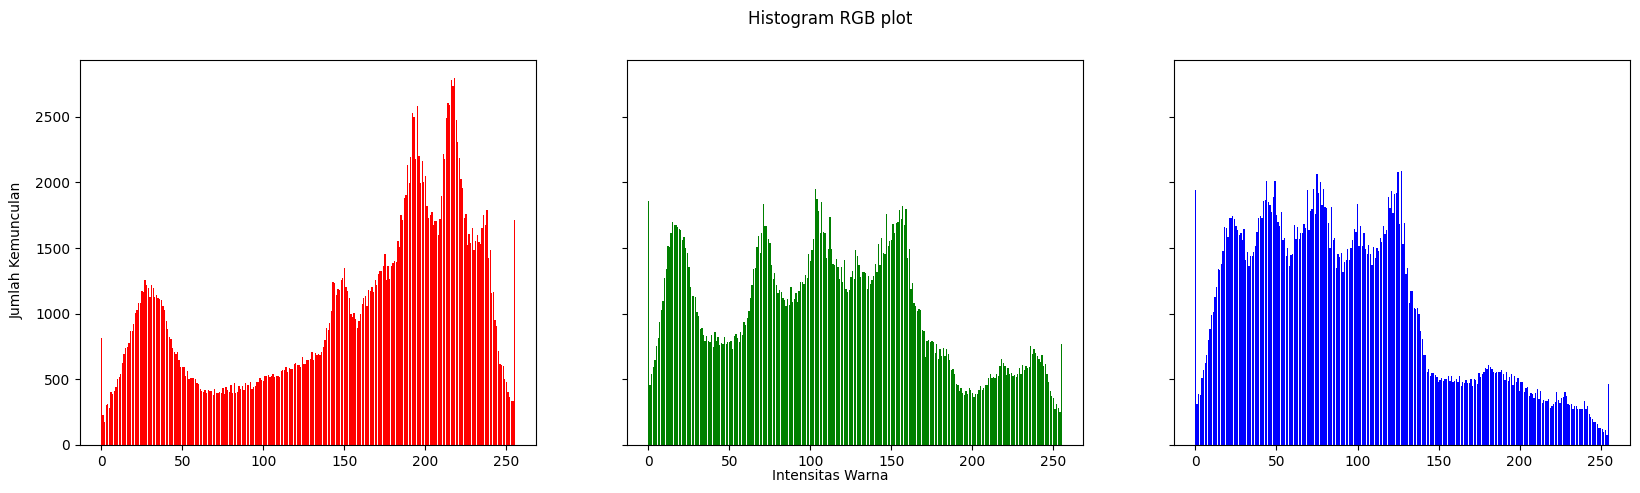

In [4]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
  for x in range(0, width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()
#

In [5]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [6]:
CONTOH = '/content/drive/MyDrive/PCVK/Images'
BASE = '/content/drive/MyDrive/PCVK/Images'

**1A. Verifikasi pada lena.jpg**

In [7]:
gray_lena = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)

# Histogram manual
hist_manual = histogram_manual(gray_lena)

# Histogram menggunakan NumPy
hist_numpy, _ = np.histogram(
    gray_lena,
    bins=256,
    range=(0, 256)
)

# Histogram menggunakan OpenCV
hist_cv = cv.calcHist(
    [gray_lena],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# Hitung selisih maksimum
selisih_manual_numpy = np.max(np.abs(hist_manual - hist_numpy))
selisih_manual_cv = np.max(np.abs(hist_manual - hist_cv))
selisih_numpy_cv = np.max(np.abs(hist_numpy - hist_cv))

print('Selisih maksimum Manual vs NumPy :', selisih_manual_numpy)
print('Selisih maksimum Manual vs CV2   :', selisih_manual_cv)
print('Selisih maksimum NumPy vs CV2    :', selisih_numpy_cv)

Selisih maksimum Manual vs NumPy : 0
Selisih maksimum Manual vs CV2   : 0.0
Selisih maksimum NumPy vs CV2    : 0.0


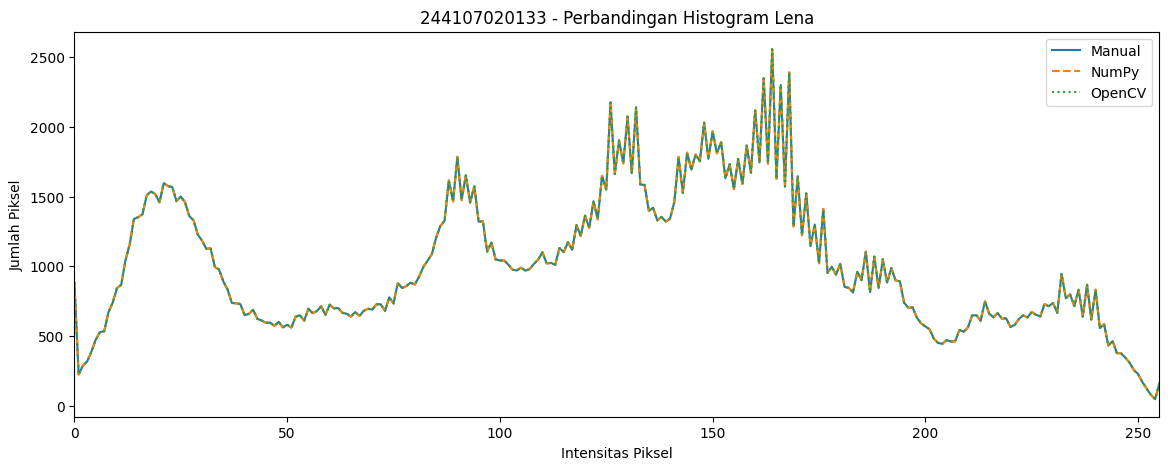

In [8]:
# Menampilkan ketiga histogram
plt.figure(figsize=(14, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_numpy, linestyle='--', label='NumPy')
plt.plot(hist_cv, linestyle=':', label='OpenCV')

plt.title(NIM + ' - Perbandingan Histogram Lena')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])
plt.legend()

plt.show()

**1B. Ulangi pada KTM1b.jpg**

In [10]:
gray_ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

# Histogram manual
hist_manual_ktm = histogram_manual(gray_ktm1b)

# Histogram NumPy
hist_numpy_ktm, _ = np.histogram(
    gray_ktm1b,
    bins=256,
    range=(0, 256)
)

# Histogram OpenCV
hist_cv_ktm = cv.calcHist(
    [gray_ktm1b],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# Selisih maksimum
selisih_manual_numpy = np.max(
    np.abs(hist_manual_ktm - hist_numpy_ktm)
)

selisih_manual_cv = np.max(
    np.abs(hist_manual_ktm - hist_cv_ktm)
)

selisih_numpy_cv = np.max(
    np.abs(hist_numpy_ktm - hist_cv_ktm)
)

print('Selisih maksimum Manual vs NumPy :', selisih_manual_numpy)
print('Selisih maksimum Manual vs CV2   :', selisih_manual_cv)
print('Selisih maksimum NumPy vs CV2    :', selisih_numpy_cv)

Selisih maksimum Manual vs NumPy : 0
Selisih maksimum Manual vs CV2   : 0.0
Selisih maksimum NumPy vs CV2    : 0.0


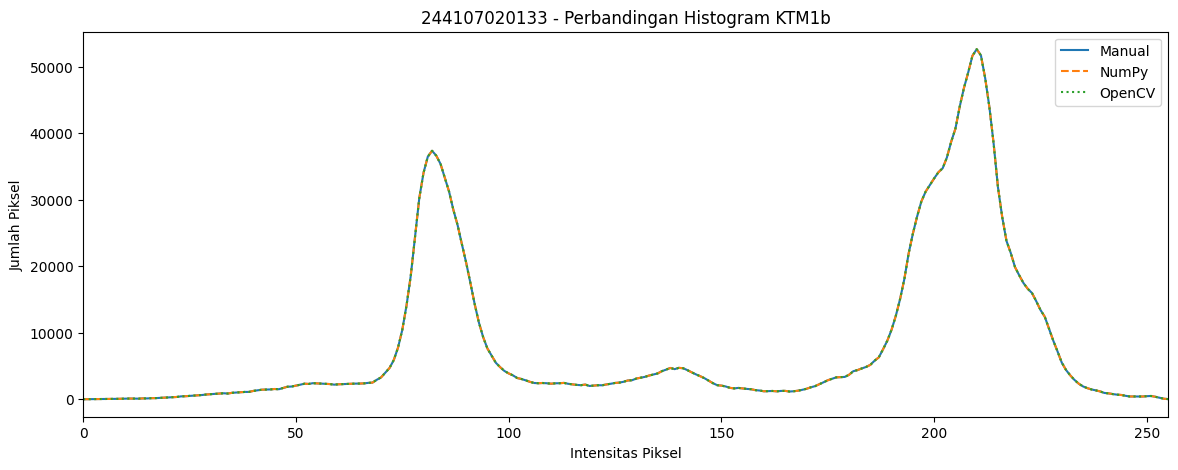

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(hist_manual_ktm, label='Manual')
plt.plot(hist_numpy_ktm, linestyle='--', label='NumPy')
plt.plot(hist_cv_ktm, linestyle=':', label='OpenCV')

plt.title(NIM + ' - Perbandingan Histogram KTM1b')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])
plt.legend()

plt.show()

**2. Histogram Ternormalisasi dan CDF KTM1a–KTM1d**

In [12]:
def histogram_dan_cdf(gray):
    hist = histogram_manual(gray)

    # Histogram ternormalisasi
    p = hist / gray.size

    # CDF
    cdf = np.cumsum(p)

    return p, cdf

In [13]:
nama_file = [
    'KTM1a.jpg',
    'KTM1b.jpg',
    'KTM1c.jpg',
    'KTM1d.jpg'
]

judul = [
    'KTM1a - Ruangan Gelap',
    'KTM1b - Lampu Ruangan',
    'KTM1c - Flash',
    'KTM1d - Cahaya Matahari'
]

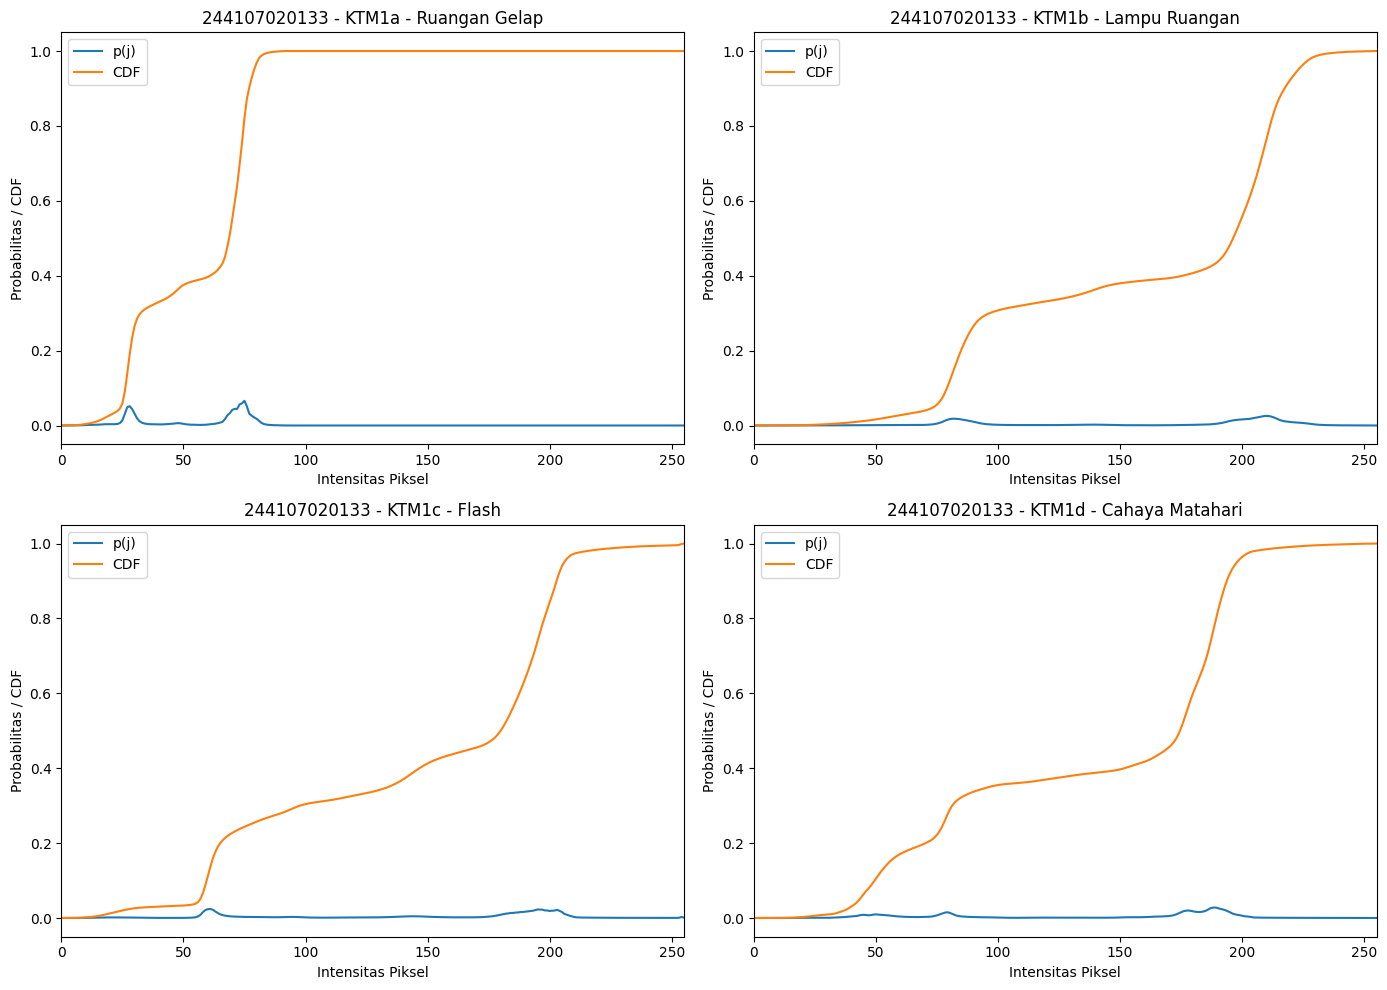

In [14]:
plt.figure(figsize=(14, 10))

for i, (file, nama) in enumerate(zip(nama_file, judul), 1):

    gray = cv.imread(
        BASE + '/' + file,
        cv.IMREAD_GRAYSCALE
    )

    p, cdf = histogram_dan_cdf(gray)

    plt.subplot(2, 2, i)

    plt.plot(p, label='p(j)')
    plt.plot(cdf, label='CDF')

    plt.title(NIM + ' - ' + nama)
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Probabilitas / CDF')
    plt.xlim([0, 255])
    plt.legend()

plt.tight_layout()
plt.show()

In [15]:
for file, nama in zip(nama_file, judul):

    gray = cv.imread(
        BASE + '/' + file,
        cv.IMREAD_GRAYSCALE
    )

    print(
        nama,
        '- Rata-rata intensitas:',
        round(gray.mean(), 2)
    )

KTM1a - Ruangan Gelap - Rata-rata intensitas: 56.64
KTM1b - Lampu Ruangan - Rata-rata intensitas: 161.66
KTM1c - Flash - Rata-rata intensitas: 146.81
KTM1d - Cahaya Matahari - Rata-rata intensitas: 139.42


**3. Perbandingan PARAM['bins'] dengan 256 Bin**

In [17]:
print("Jumlah bin berdasarkan NIM =", PARAM['bins'])

Jumlah bin berdasarkan NIM = 16


In [18]:
gray = cv.imread(
    BASE + '/KTM1b.jpg',
    cv.IMREAD_GRAYSCALE
)

In [19]:
hist_param, batas_param = np.histogram(
    gray,
    bins=PARAM['bins'],
    range=(0, 256)
)

hist_256, batas_256 = np.histogram(
    gray,
    bins=256,
    range=(0, 256)
)

In [20]:
pusat_param = (
    batas_param[:-1] + batas_param[1:]
) / 2

pusat_256 = (
    batas_256[:-1] + batas_256[1:]
) / 2

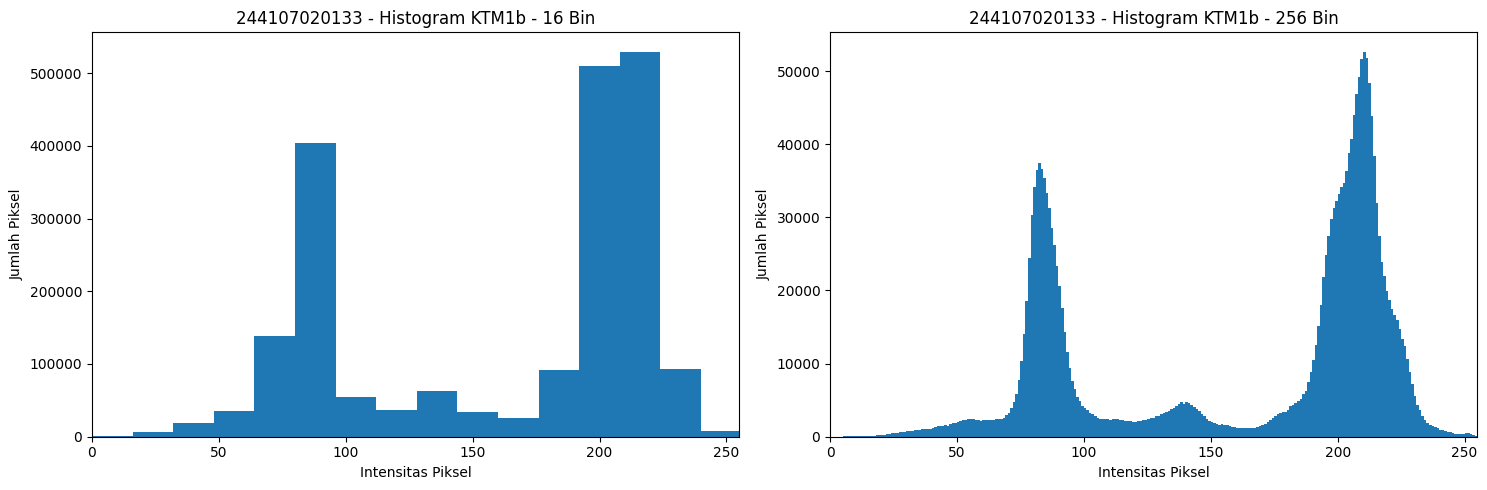

In [21]:
plt.figure(figsize=(15, 5))

# PARAM['bins']
plt.subplot(1, 2, 1)

plt.bar(
    pusat_param,
    hist_param,
    width=256 / PARAM['bins']
)

plt.title(
    NIM + ' - Histogram KTM1b - ' +
    str(PARAM['bins']) + ' Bin'
)

plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])


# 256 bin
plt.subplot(1, 2, 2)

plt.bar(
    pusat_256,
    hist_256,
    width=1
)

plt.title(
    NIM + ' - Histogram KTM1b - 256 Bin'
)

plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

**E-2.1 Histogram Equalization Manual**

**A. Tahap 1 — lena_lc.jpg**

In [22]:
gray_lena_lc = cv.imread(
    CONTOH + '/lena_lc.jpg',
    cv.IMREAD_GRAYSCALE
)

if gray_lena_lc is None:
    print('lena_lc.jpg gagal dibaca')
else:
    print('lena_lc.jpg berhasil dibaca')
    print('Ukuran:', gray_lena_lc.shape)

lena_lc.jpg berhasil dibaca
Ukuran: (512, 512)


In [23]:
def equalization_manual(gray):
    hist = histogram_manual(gray)

    # Probabilitas
    p = hist / gray.size

    # CDF
    cdf = np.cumsum(p)

    # Transformasi intensitas
    transform = np.round(255 * cdf).astype(np.uint8)

    # Terapkan mapping
    hasil = transform[gray]

    return hasil, hist, cdf, transform

In [24]:
eq_manual_lena, hist_lena, cdf_lena, transform_lena = equalization_manual(
    gray_lena_lc
)

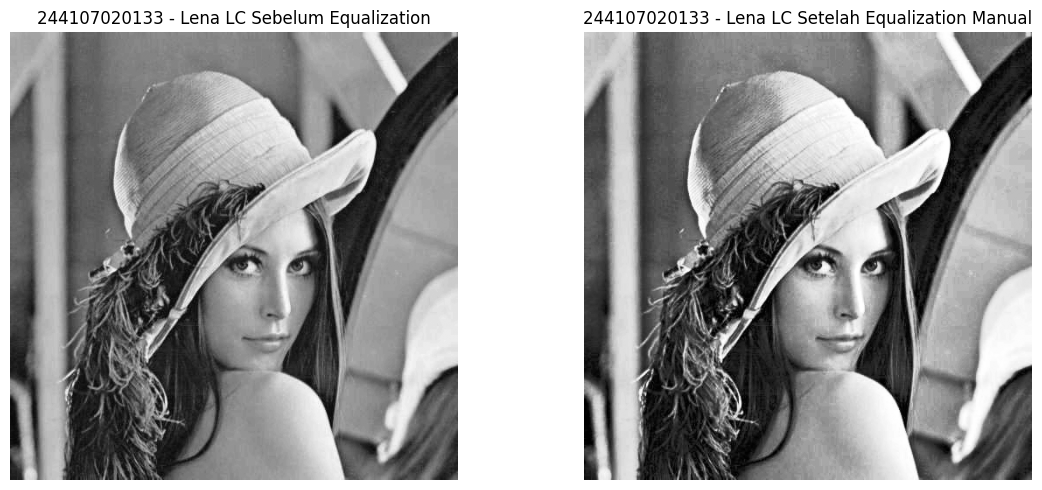

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_lena_lc, cmap='gray')
plt.title(NIM + ' - Lena LC Sebelum Equalization')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(eq_manual_lena, cmap='gray')
plt.title(NIM + ' - Lena LC Setelah Equalization Manual')
plt.axis('off')

plt.tight_layout()
plt.show()

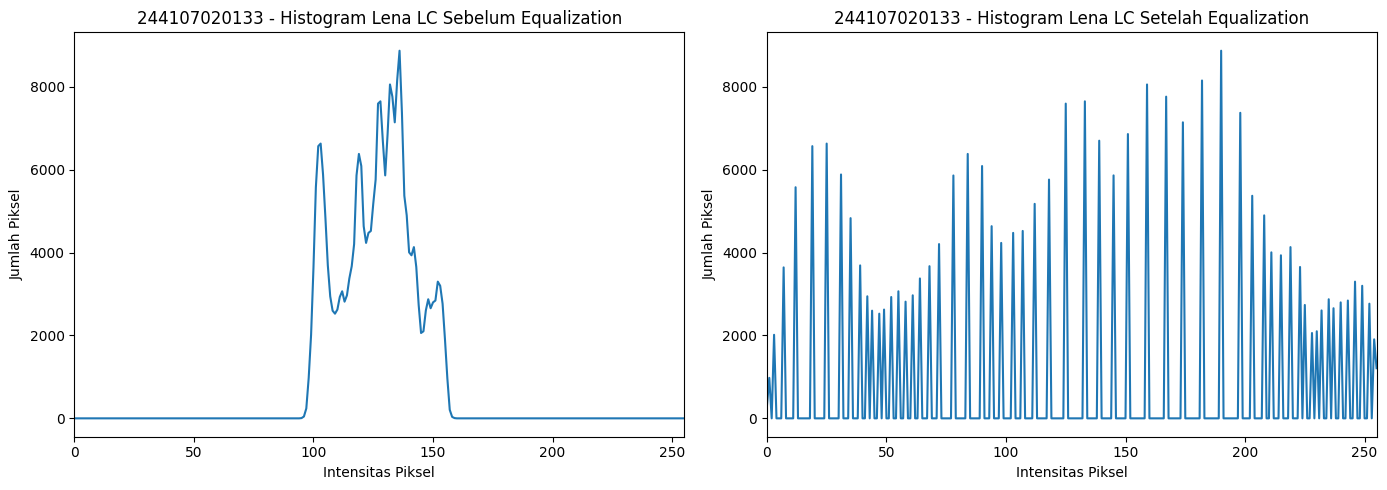

In [26]:
hist_sebelum = histogram_manual(gray_lena_lc)
hist_sesudah = histogram_manual(eq_manual_lena)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_sebelum)
plt.title(NIM + ' - Histogram Lena LC Sebelum Equalization')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])

plt.subplot(1, 2, 2)
plt.plot(hist_sesudah)
plt.title(NIM + ' - Histogram Lena LC Setelah Equalization')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

**B. Tahap 2 — KTM1a**

In [27]:
gray_ktm1a = cv.imread(
    BASE + '/KTM1a.jpg',
    cv.IMREAD_GRAYSCALE
)

if gray_ktm1a is None:
    print('KTM1a.jpg gagal dibaca')
else:
    print('KTM1a.jpg berhasil dibaca')

KTM1a.jpg berhasil dibaca


In [28]:
eq_manual_ktm1a, hist_ktm1a, cdf_ktm1a, transform_ktm1a = equalization_manual(
    gray_ktm1a
)

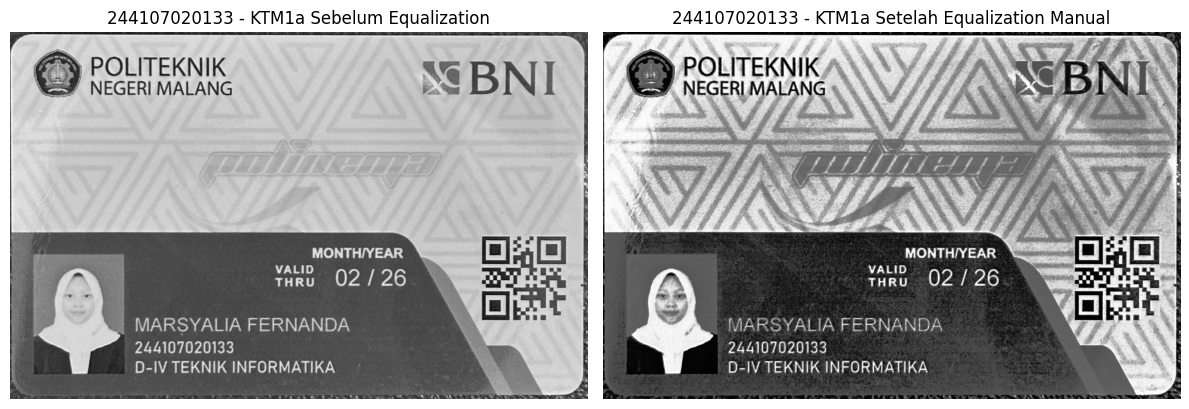

In [29]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_ktm1a, cmap='gray')
plt.title(NIM + ' - KTM1a Sebelum Equalization')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(eq_manual_ktm1a, cmap='gray')
plt.title(NIM + ' - KTM1a Setelah Equalization Manual')
plt.axis('off')

plt.tight_layout()
plt.show()

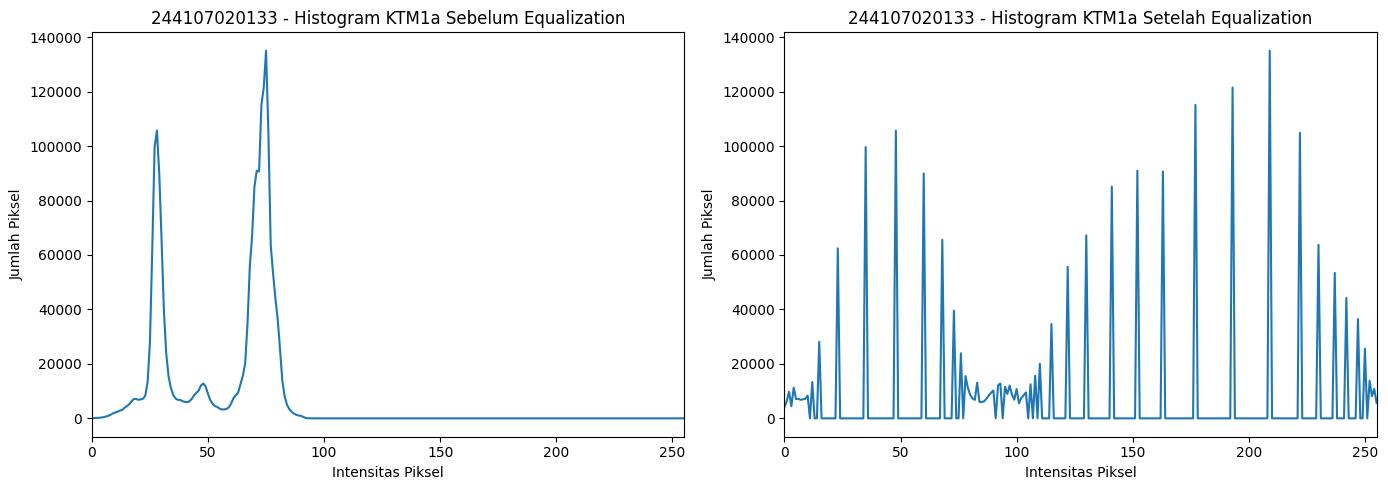

In [30]:
hist_sebelum = histogram_manual(gray_ktm1a)
hist_sesudah = histogram_manual(eq_manual_ktm1a)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_sebelum)
plt.title(NIM + ' - Histogram KTM1a Sebelum Equalization')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])

plt.subplot(1, 2, 2)
plt.plot(hist_sesudah)
plt.title(NIM + ' - Histogram KTM1a Setelah Equalization')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])

plt.tight_layout()
plt.show()

**E-2.2 Bandingkan dengan cv.equalizeHist**

In [31]:
eq_cv_lena = cv.equalizeHist(gray_lena_lc)

selisih_lena = np.max(
    np.abs(
        eq_manual_lena.astype(np.int16) -
        eq_cv_lena.astype(np.int16)
    )
)

print('Selisih maksimum Lena manual vs cv.equalizeHist =', selisih_lena)

Selisih maksimum Lena manual vs cv.equalizeHist = 0


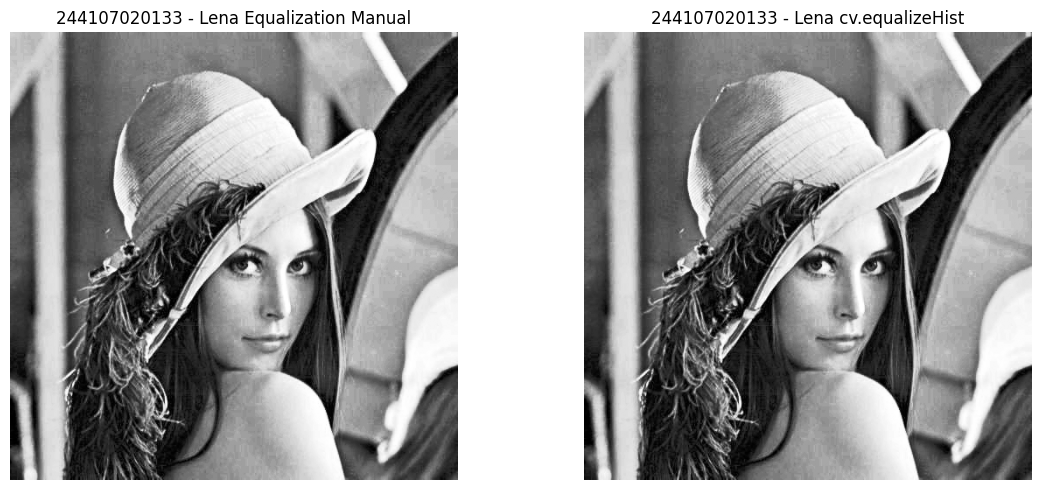

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(eq_manual_lena, cmap='gray')
plt.title(NIM + ' - Lena Equalization Manual')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(eq_cv_lena, cmap='gray')
plt.title(NIM + ' - Lena cv.equalizeHist')
plt.axis('off')

plt.tight_layout()
plt.show()

In [33]:
eq_cv_ktm1a = cv.equalizeHist(gray_ktm1a)

selisih_ktm = np.max(
    np.abs(
        eq_manual_ktm1a.astype(np.int16) -
        eq_cv_ktm1a.astype(np.int16)
    )
)

print('Selisih maksimum KTM1a manual vs cv.equalizeHist =', selisih_ktm)

Selisih maksimum KTM1a manual vs cv.equalizeHist = 0


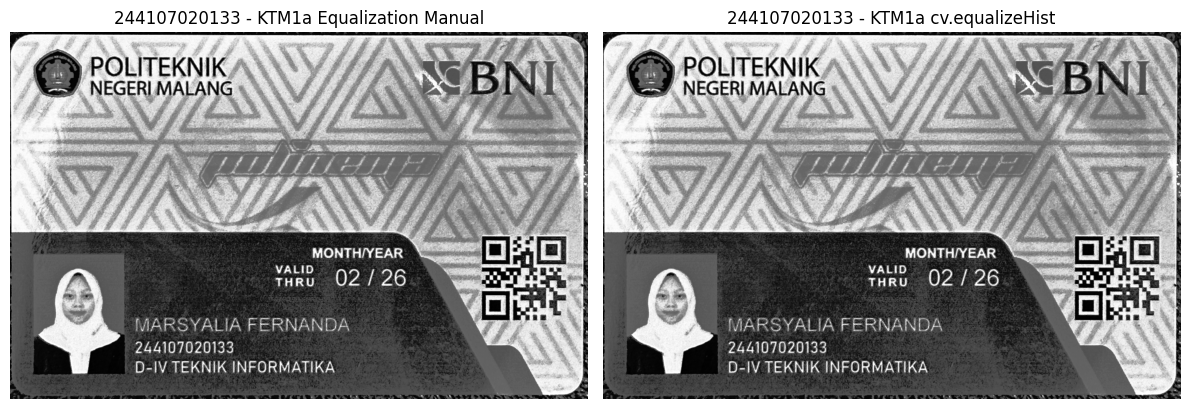

In [34]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(eq_manual_ktm1a, cmap='gray')
plt.title(NIM + ' - KTM1a Equalization Manual')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(eq_cv_ktm1a, cmap='gray')
plt.title(NIM + ' - KTM1a cv.equalizeHist')
plt.axis('off')

plt.tight_layout()
plt.show()

**E-2.3 Equalization citra berwarna**

In [35]:
bgr_lena = cv.imread(CONTOH + '/lena.jpg')

kanal = list(cv.split(bgr_lena))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb_lena = cv.merge(kanal)

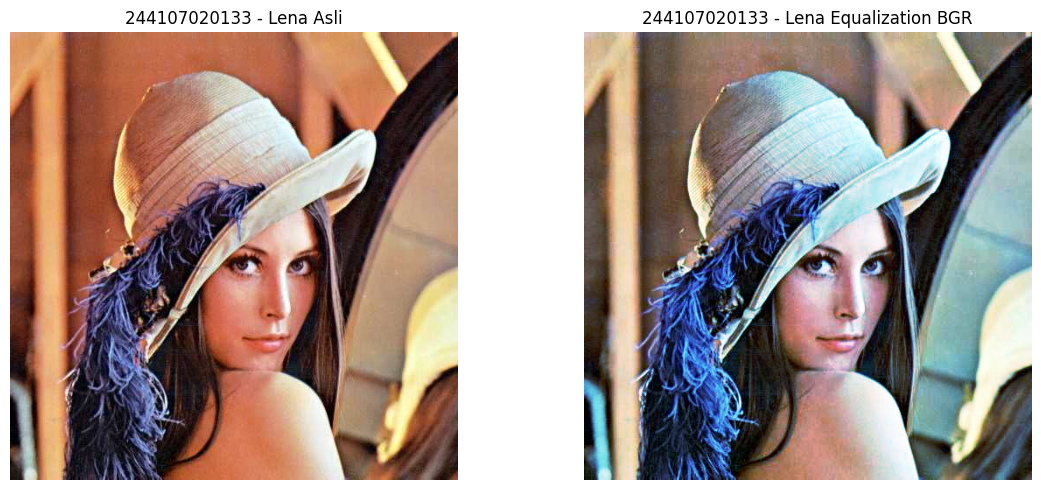

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr_lena, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Lena Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_rgb_lena, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Lena Equalization BGR')
plt.axis('off')

plt.tight_layout()
plt.show()

In [37]:
bgr = cv.imread(BASE + '/KTM1d.jpg')

kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

**E-2.4 Equalization kanal terang Y, V, dan L**

In [39]:
# YCrCb
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

he_y = cv.cvtColor(
    cv.merge([
        cv.equalizeHist(y),
        cr,
        cb
    ]),
    cv.COLOR_YCrCb2BGR
)

# HSV
h, sat, v = cv.split(
    cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
)

he_v = cv.cvtColor(
    cv.merge([
        h,
        sat,
        cv.equalizeHist(v)
    ]),
    cv.COLOR_HSV2BGR
)

# LAB
l, a, b = cv.split(
    cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
)

he_l = cv.cvtColor(
    cv.merge([
        cv.equalizeHist(l),
        a,
        b
    ]),
    cv.COLOR_LAB2BGR
)

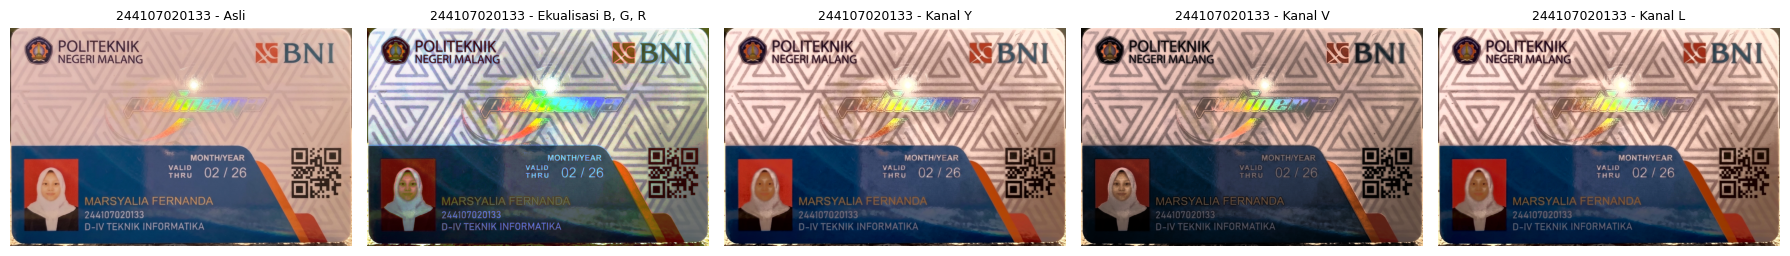

In [40]:
judul = [
    'Asli',
    'Ekualisasi B, G, R',
    'Kanal Y',
    'Kanal V',
    'Kanal L'
]

citra = [
    bgr,
    he_rgb,
    he_y,
    he_v,
    he_l
]

plt.figure(figsize=(18, 4))

for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)

    plt.imshow(
        cv.cvtColor(c, cv.COLOR_BGR2RGB)
    )

    plt.title(
        NIM + ' - ' + t,
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [41]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(
        asli,
        cv.COLOR_BGR2HSV
    )[:, :, 0].astype(np.int16)

    h2 = cv.cvtColor(
        hasil,
        cv.COLOR_BGR2HSV
    )[:, :, 0].astype(np.int16)

    d = np.abs(h1 - h2)

    # Hue OpenCV melingkar 0-179
    d = np.minimum(d, 180 - d)

    return d.mean()

In [42]:
print(
    '%-22s %16s %16s' %
    ('Cara', 'geser Hue (der)', 'rerata terang')
)

for t, c in zip(judul, citra):

    print(
        '%-22s %16.2f %16.1f' %
        (
            t,
            geser_hue(bgr, c) * 2,
            cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        )
    )

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            139.4
Ekualisasi B, G, R                61.24            129.0
Kanal Y                            1.70            129.2
Kanal V                            0.78            107.2
Kanal L                            2.55            123.8


**E-2.4 Tambahan CLAHE**

In [43]:
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(
        PARAM['tile'],
        PARAM['tile']
    )
)

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

y_clahe = clahe.apply(y)

clahe_y = cv.cvtColor(
    cv.merge([
        y_clahe,
        cr,
        cb
    ]),
    cv.COLOR_YCrCb2BGR
)

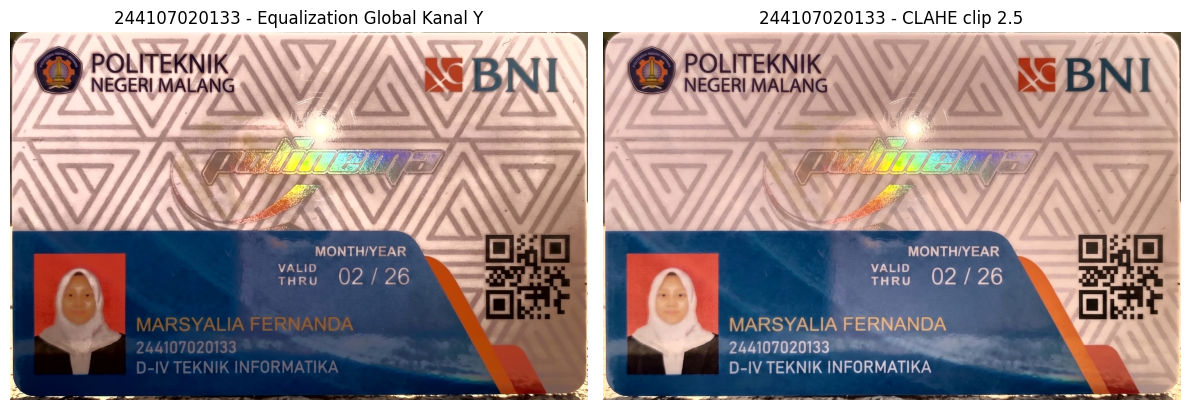

In [44]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization Global Kanal Y')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(clahe_y, cv.COLOR_BGR2RGB))
plt.title(
    NIM + ' - CLAHE clip ' +
    str(PARAM['clip'])
)
plt.axis('off')

plt.tight_layout()
plt.show()

In [45]:
print(
    'Global Y - Geser Hue:',
    round(geser_hue(bgr, he_y) * 2, 2)
)

print(
    'Global Y - Rerata terang:',
    round(
        cv.cvtColor(
            he_y,
            cv.COLOR_BGR2GRAY
        ).mean(),
        2
    )
)

print(
    'CLAHE Y - Geser Hue:',
    round(
        geser_hue(bgr, clahe_y) * 2,
        2
    )
)

print(
    'CLAHE Y - Rerata terang:',
    round(
        cv.cvtColor(
            clahe_y,
            cv.COLOR_BGR2GRAY
        ).mean(),
        2
    )
)

Global Y - Geser Hue: 1.7
Global Y - Rerata terang: 129.18
CLAHE Y - Geser Hue: 0.15
CLAHE Y - Rerata terang: 140.53


**1. Ekualisasi global pada KTM1a**

In [46]:
# a. Manual dan cv.equalizeHist
eq_manual_ktm1a
eq_cv_ktm1a

array([[ 7,  7,  7, ..., 81, 73, 35],
       [ 8,  8,  9, ..., 76, 48, 15],
       [12, 12, 15, ..., 35, 15, 10],
       ...,
       [12, 12, 12, ...,  7,  6,  6],
       [23, 15, 12, ..., 15,  9,  8],
       [35, 23, 15, ..., 35,  9,  8]], dtype=uint8)

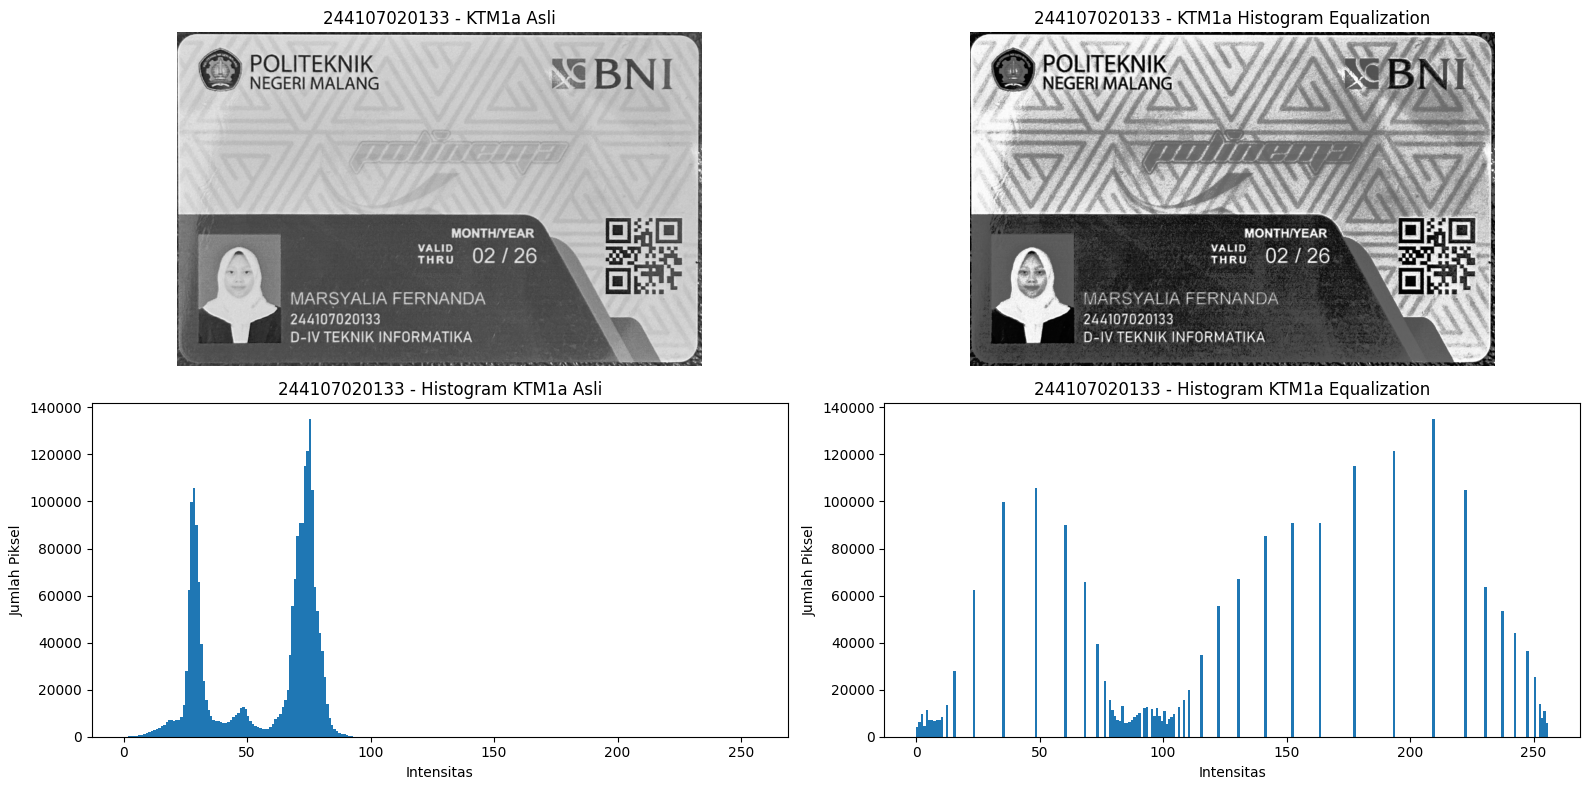

In [47]:
#Citra asli, hasil equalization, dan histogram satu layout

plt.figure(figsize=(16, 8))

# Citra asli
plt.subplot(2, 2, 1)
plt.imshow(gray_ktm1a, cmap='gray')
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')

# Hasil equalization
plt.subplot(2, 2, 2)
plt.imshow(eq_cv_ktm1a, cmap='gray')
plt.title(NIM + ' - KTM1a Histogram Equalization')
plt.axis('off')

# Histogram asli
plt.subplot(2, 2, 3)
plt.hist(
    gray_ktm1a.ravel(),
    bins=256,
    range=(0, 256)
)
plt.title(NIM + ' - Histogram KTM1a Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

# Histogram hasil
plt.subplot(2, 2, 4)
plt.hist(
    eq_cv_ktm1a.ravel(),
    bins=256,
    range=(0, 256)
)
plt.title(NIM + ' - Histogram KTM1a Equalization')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

In [48]:
# Hitung PSNR

psnr = cv.PSNR(
    gray_ktm1a,
    eq_cv_ktm1a
)

print('PSNR KTM1a =', round(psnr, 2), 'dB')

PSNR KTM1a = 8.78 dB


**2. Ekualisasi Lokal dengan CLAHE**

In [49]:
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(
        PARAM['tile'],
        PARAM['tile']
    )
)

clahe_ktm1a = clahe.apply(gray_ktm1a)

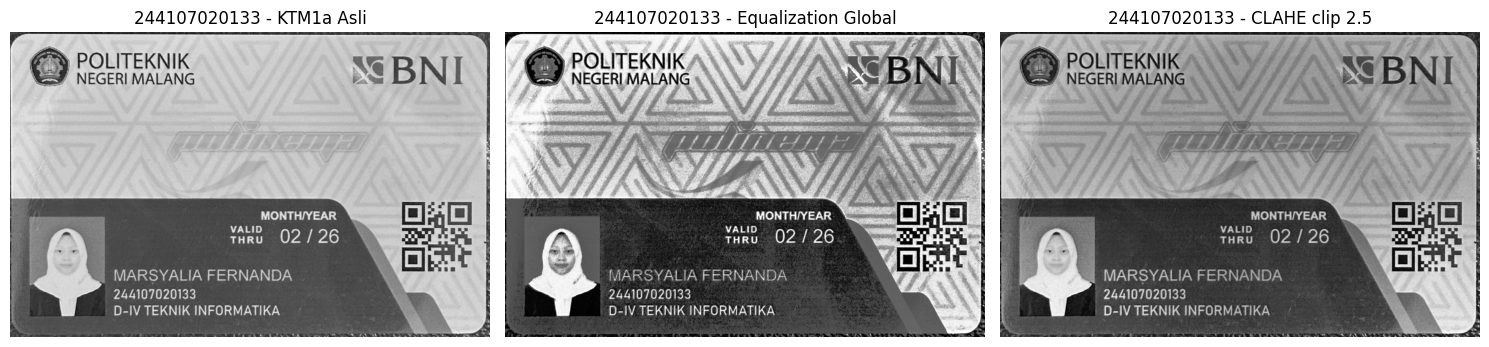

In [50]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray_ktm1a, cmap='gray')
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_cv_ktm1a, cmap='gray')
plt.title(NIM + ' - Equalization Global')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(clahe_ktm1a, cmap='gray')
plt.title(
    NIM + ' - CLAHE clip ' +
    str(PARAM['clip'])
)
plt.axis('off')

plt.tight_layout()
plt.show()

**2B. Tiga nilai clipLimit lain**

In [51]:
clip_asli = PARAM['clip']

clip_values = [
    max(0.5, clip_asli - 0.5),
    clip_asli,
    clip_asli + 0.5,
    clip_asli + 1.0
]

print(clip_values)

[2.0, 2.5, 3.0, 3.5]


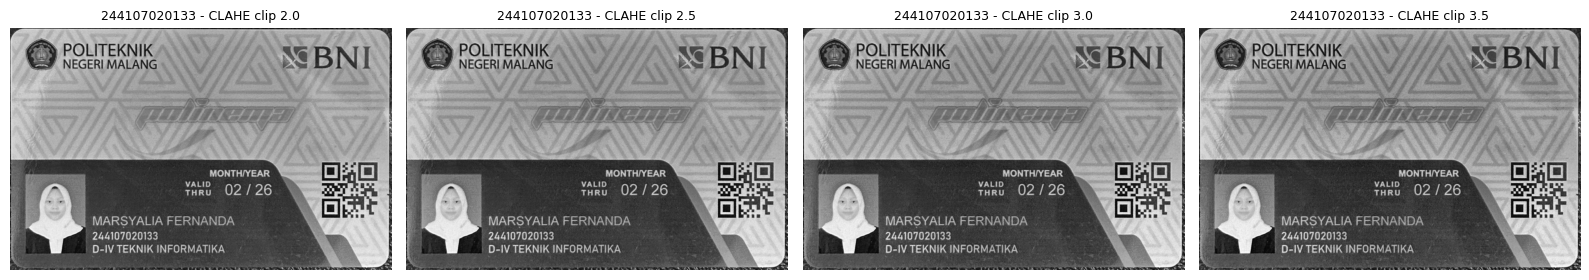

In [52]:
plt.figure(figsize=(16, 4))

for i, clip in enumerate(clip_values, 1):

    clahe_uji = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(
            PARAM['tile'],
            PARAM['tile']
        )
    )

    hasil = clahe_uji.apply(gray_ktm1a)

    plt.subplot(1, 4, i)
    plt.imshow(hasil, cmap='gray')

    plt.title(
        NIM + ' - CLAHE clip ' +
        str(clip),
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()
plt.show()